# F-16: continuously learning iADP vs PID under aerodynamic failure

A 500-second flight with a 30% loss of stabilator aerodynamic effectiveness at 137 s. The failure schedule is unknown to the controllers. iADP continues identification and critic learning throughout the episode; PID gains stay fixed. There are no resets or parameter freezes at the event.

For `C ∈ {Cy, Cm}`, the failure uses `C_fault(δ) = C(0) + η [C(δ) − C(0)]`, with `η=0.7` after the event. Actual measured stabilator position, the original actuator, and physical limits are retained. This is a parametric effectiveness test, not a validated model of a particular mechanical failure.

iADP parameters were selected from six candidates using cost on a **healthy** 500-second reference trajectory with different frequencies. PID was retuned on the healthy aircraft with wider search bounds; Ki no longer reaches the old limit of 500. Offline tuning costs were not equalized.

In [1]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import Markdown, display

repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tensoraerospace").is_dir())
sys.path.insert(0, str(repo))
from example.reinforcement_learning.incremental_adp import example_iadp_aero_effectiveness_f16 as demo
from example.reinforcement_learning.incremental_adp.example_iadp_small_fault_f16 import Experiment
%matplotlib inline


In [2]:
cfg = Experiment(duration=500.0, fault_time=137.0, loss=0.0, phase=0.0)
fault = demo.AeroFault(time_s=137.0, effectiveness=0.7)
traces, learning, report = demo.run_comparison(cfg, fault)


Running healthy_iadp, 500 s


Running healthy_pid, 500 s


Running fault_iadp, 500 s


Running fault_pid, 500 s


In [3]:
rows = ["| Scenario | Post-event RMSE, °/s | RMSE over last 100 s, °/s |", "|---|---:|---:|"]
for name, m in report["metrics"].items():
    rows.append(f"| {name} | {m['after_fault']['rmse_deg_s']:.6f} | {m['last_100_s']['rmse_deg_s']:.6f} |")
display(Markdown("\n".join(rows)))
a = report["metrics"]["fault_iadp"]
p = report["metrics"]["fault_pid"]
print("Post-failure RMSE reduction, %:", 100 * (1 - a['after_fault']['rmse_deg_s'] / p['after_fault']['rmse_deg_s']))
print("PID Kp, Ki, Kd:", report['pid_gains'])
print("iADP model change after the event:", a['model_change_after_event'])
print("iADP critic change after the event:", a['critic_change_after_event'])


| Scenario | Post-event RMSE, °/s | RMSE over last 100 s, °/s |
|---|---:|---:|
| healthy_iadp | 0.012493 | 0.019350 |
| healthy_pid | 0.005140 | 0.005138 |
| fault_iadp | 0.017749 | 0.006591 |
| fault_pid | 0.020507 | 0.007840 |

Post-failure RMSE reduction, %: 13.446521471930218
PID Kp, Ki, Kd: [-135.60695234860972, -982.6934506639378, -0.0020707024599338265]
iADP model change after the event: 0.005906102460599227
iADP critic change after the event: 1.0602459129568373


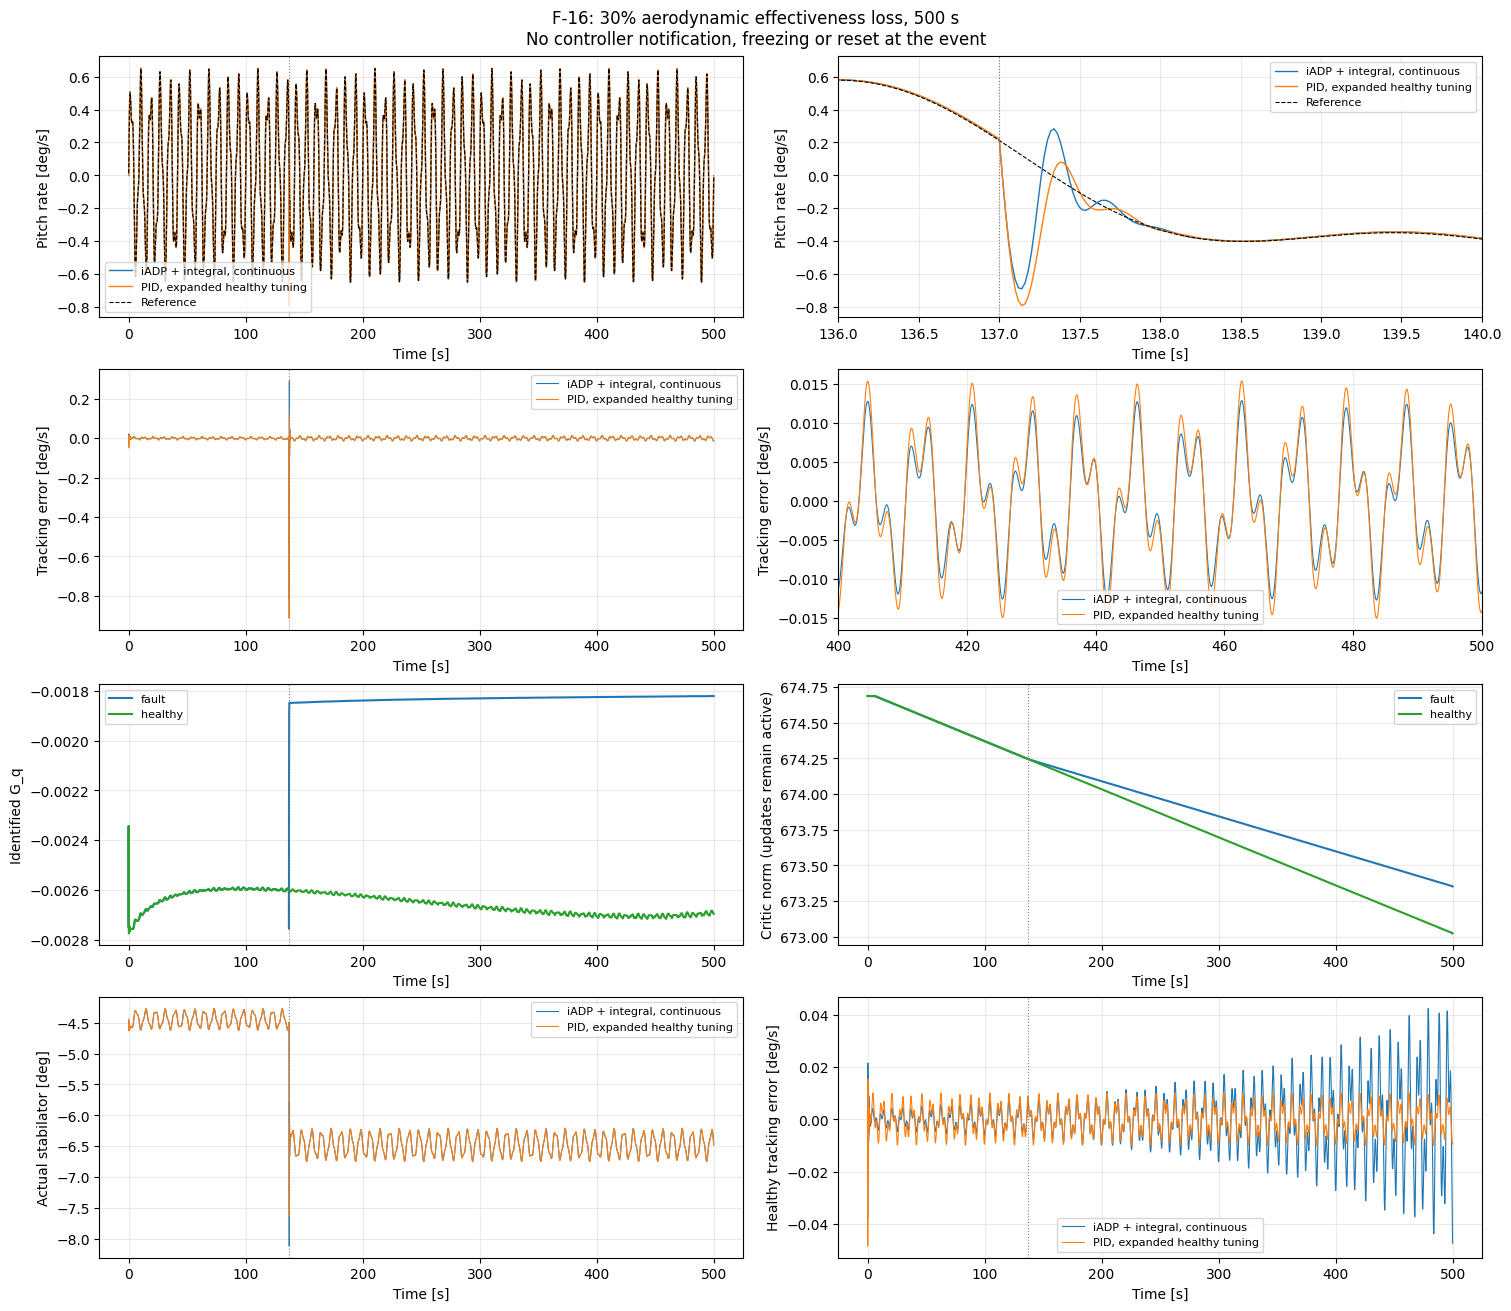

Results: /home/mr8bit/Projects/TensorAeroSpace/outputs/f16-iadp-effectiveness/notebook


In [4]:
import matplotlib.pyplot as plt
output = repo / "outputs" / "f16-iadp-effectiveness" / "notebook"
figure = demo.save_results(traces, learning, report, output)
display(figure)
plt.close(figure)
print("Results:", output)


## Conclusion and limits

For this 30% aerodynamic-effectiveness loss, continuously learning iADP with an integral state is more accurate than the strengthened, nominally tuned PID both over the entire post-event interval and over the last 100 seconds. Most adaptation occurs in the identifier; the critic updates slowly but remains active.

PID is more accurate on the healthy aircraft. PID also performed better at 40% effectiveness loss. This is a specific reproducible improvement, not universal iADP superiority or a proof of infinite-horizon convergence.

Tests with other event times, another phase, 20% loss, physics steps of 10 and 5 ms, and complete tuning logs are in `reports/iadp-f16-effectiveness-validation.md` and `.json`. The control period remains 20 ms in every test.

Original iADP formulation and discussion of continuous learning: [Konatala et al., 2024](https://doi.org/10.2514/6.2024-2402). The integral state and parametric aerodynamic failure extend this example; the complete flight experiment from the paper is not reproduced here.